In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("custdata.tsv", sep="\t")

df.head()

,custid,sex,is.employed,income,marital.stat,health.ins,housing.type,recent.move,num.vehicles,age,state.of.res
0,2068,F,NaN,11300,Married,True,Homeowner free and clear,False,2.0,49.0,Michigan
1,2073,F,NaN,0,Married,True,Rented,True,3.0,40.0,Florida
2,2848,M,True,4500,Never Married,False,Rented,True,3.0,22.0,Georgia
3,5641,M,True,20000,Never Married,False,Occupied with no rent,False,0.0,22.0,New Mexico
4,6369,F,True,12000,Never Married,True,Rented,True,1.0,31.0,Florida


In [2]:
df.columns

Index(['custid', 'sex', 'is.employed', 'income', 'marital.stat', 'health.ins',
       'housing.type', 'recent.move', 'num.vehicles', 'age', 'state.of.res'],
      dtype='str')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   custid        1000 non-null   int64  
 1   sex           1000 non-null   str    
 2   is.employed   672 non-null    object 
 3   income        1000 non-null   int64  
 4   marital.stat  1000 non-null   str    
 5   health.ins    1000 non-null   bool   
 6   housing.type  944 non-null    str    
 7   recent.move   944 non-null    object 
 8   num.vehicles  944 non-null    float64
 9   age           1000 non-null   float64
 10  state.of.res  1000 non-null   str    
dtypes: bool(1), float64(2), int64(2), object(2), str(4)
memory usage: 79.2+ KB


In [4]:
df.head(10)

,custid,sex,is.employed,income,marital.stat,health.ins,housing.type,recent.move,num.vehicles,age,state.of.res
0,2068,F,NaN,11300,Married,True,Homeowner free and clear,False,2.0,49.0,Michigan
1,2073,F,NaN,0,Married,True,Rented,True,3.0,40.0,Florida
2,2848,M,True,4500,Never Married,False,Rented,True,3.0,22.0,Georgia
3,5641,M,True,20000,Never Married,False,Occupied with no rent,False,0.0,22.0,New Mexico
4,6369,F,True,12000,Never Married,True,Rented,True,1.0,31.0,Florida
5,8322,F,True,180000,Never Married,True,Homeowner with mortgage/loan,False,1.0,40.0,New York
6,8521,M,True,120000,Never Married,True,Homeowner free and clear,True,1.0,39.0,Idaho
7,12195,M,True,40000,Married,True,Rented,False,3.0,48.0,Michigan
8,14989,M,NaN,9400,Married,True,Rented,False,2.0,44.0,Illinois
9,15917,F,True,24000,Divorced/Separated,True,Homeowner free and clear,False,1.0,70.0,North Carolina


In [5]:
df["housing.type"].value_counts(dropna=False)

housing.type
Homeowner with mortgage/loan    412
Rented                          364
Homeowner free and clear        157
NaN                              56
Occupied with no rent            11
Name: count, dtype: int64

In [6]:
excluded = df["housing.type"].isna().sum()
excluded

np.int64(56)

In [7]:
clean_df = df.dropna(subset=["housing.type"])

clean_df["housing.type"].value_counts()

housing.type
Homeowner with mortgage/loan    412
Rented                          364
Homeowner free and clear        157
Occupied with no rent            11
Name: count, dtype: int64

In [8]:
housing_counts = clean_df["housing.type"].value_counts().sort_values(ascending=False)

housing_counts

housing.type
Homeowner with mortgage/loan    412
Rented                          364
Homeowner free and clear        157
Occupied with no rent            11
Name: count, dtype: int64

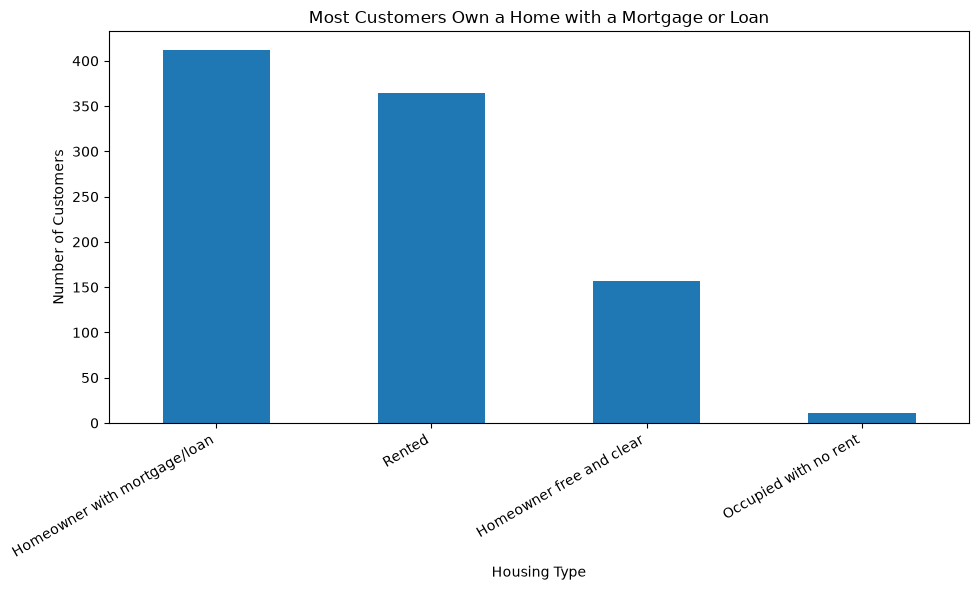

In [9]:
plt.figure(figsize=(10, 6))

housing_counts.plot(kind="bar")

plt.title("Most Customers Own a Home with a Mortgage or Loan")
plt.xlabel("Housing Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.show()

Before creating the bar chart, I checked the housing type column for missing values. I found 56 rows with no housing type information and removed them from the data. This allowed the chart to show only the valid housing categories and their customer counts.